# QuickBite Food Delivery — Online Review Sentiment Analysis
### NLP & Sentiment Analysis — Real-Life Project

This notebook walks through the full pipeline used in the assignment:
1. Load the dataset.
2. Text preprocessing (tokenization, stopword removal, TF-IDF)
3. Train/test split
4. Build and evaluate classification models
5. Compare models.
6. Visualize sentiment trends

All data here is **synthetic**.

In [4]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")

Libraries ready.


## 1. Load the dataset

In [5]:
df = pd.read_csv('quickbite_reviews_sentiment.csv', parse_dates=['date'])
print(df.shape)
df.head()

(150, 7)


,review_id,review_text,product,sentiment,source,date,rating
0,1,Customer support ignored my Beverage complaint...,Beverage,negative,Twitter,2025-11-17,1
1,2,"My Beverage arrived on time, haven't tried it yet",Beverage,neutral,Twitter,2025-07-11,3
2,3,Late delivery and the Biryani was defective on...,Biryani,negative,App Store,2025-11-03,1
3,4,"Average Pasta, works as expected but could be ...",Pasta,neutral,App Store,2025-06-07,3
4,5,This Dessert broke my expectations in the wors...,Dessert,negative,App Store,2025-02-13,1


In [6]:
print(df['sentiment'].value_counts())
print()
print(df['source'].value_counts())

sentiment
positive    60
negative    51
neutral     39
Name: count, dtype: int64

source
App Store    85
Twitter      65
Name: count, dtype: int64


## 2. Text preprocessing

Three standard steps before modeling:
- **Tokenization—split text into individual words
- **Stopword removal—drop common words that carry little meaning ("the," "is," "and"...).
- **TF-IDF—turns cleaned text into numeric features that weigh rare, informative words more heavily than common ones

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(8)

,review_text,clean_text
0,Customer support ignored my Beverage complaint...,customer support ignored beverage complaint da...
1,"My Beverage arrived on time, haven't tried it yet",beverage arrived time havent tried yet
2,Late delivery and the Biryani was defective on...,late delivery biryani defective arrival
3,"Average Pasta, works as expected but could be ...",average pasta works expected could better
4,This Dessert broke my expectations in the wors...,dessert broke expectations worst way possible
5,Customer support ignored my Salad complaint fo...,customer support ignored salad complaint days ...
6,Comparing a few Salad options before I decide,comparing salad options decide
7,"Sushi is amazing, exceeded all expectations #r...",sushi amazing exceeded expectations recommend


In [8]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("Sample vocabulary:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (150, 568)
Sample vocabulary: ['customer', 'support', 'ignored', 'beverage', 'complaint', 'days', 'frustrating', 'customer support', 'support ignored', 'ignored beverage', 'beverage complaint', 'complaint days', 'days frustrating', 'arrived', 'time']


## 3. Train/test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 120  Test size: 30


## 4. Model selection and implementation

We train three common text-classification models and compare them:
- **Logistic Regression** — a strong, fast linear baseline
- **Multinomial Naive Bayes** — a classic, very fast text-classification model
- **Linear SVM** — often the strongest linear model for TF-IDF features

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


## 5. Evaluation and model comparison

In [11]:
results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.966667,0.969697,0.966667,0.966349
1,Logistic Regression,0.933333,0.942857,0.933333,0.931136
2,Multinomial Naive Bayes,0.933333,0.938928,0.933333,0.930032


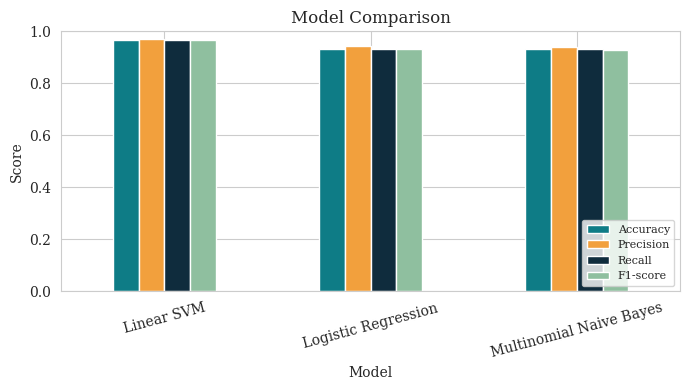

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot.bar(ax=ax, color=['#0E7C86','#F2A03D','#0F2C3D','#8FBF9F'])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Best model: Linear SVM

              precision    recall  f1-score   support

    negative       0.91      1.00      0.95        10
     neutral       1.00      0.88      0.93         8
    positive       1.00      1.00      1.00        12

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



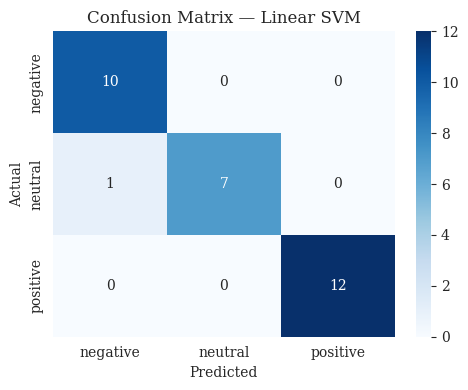

In [13]:
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
preds = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. Visualizing sentiment trends

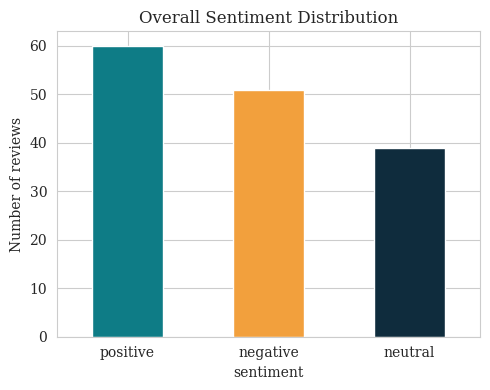

In [14]:
sent_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5,4))
sent_counts.plot.bar(color=['#0E7C86','#F2A03D','#0F2C3D'])
plt.title("Overall Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

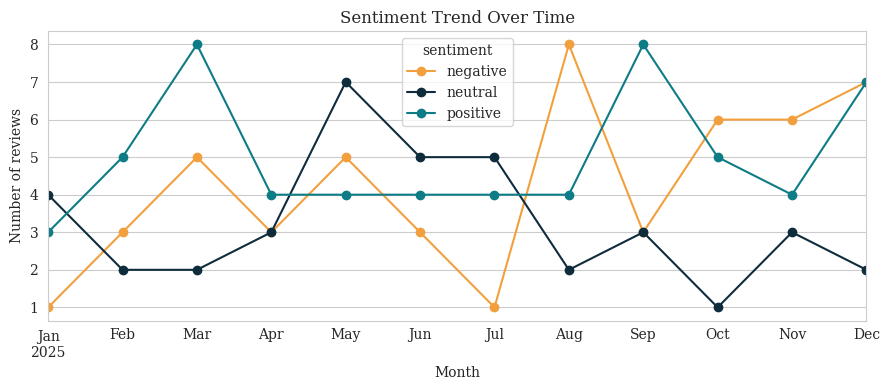

In [15]:
monthly = df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size().unstack(fill_value=0)
monthly.plot(figsize=(9,4), marker='o', color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Trend Over Time")
plt.ylabel("Number of reviews")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

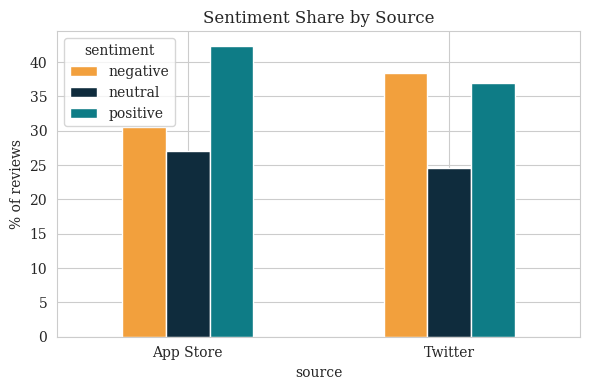

In [16]:
source_sentiment = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
source_sentiment.plot.bar(figsize=(6,4), color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Share by Source")
plt.ylabel("% of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

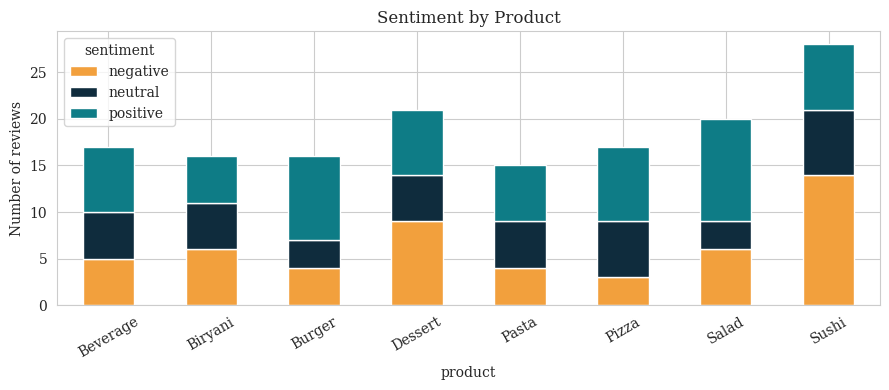

In [17]:
product_sentiment = pd.crosstab(df['product'], df['sentiment'])
product_sentiment.plot.bar(stacked=True, figsize=(9,4), color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment by Product")
plt.ylabel("Number of reviews")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Result interpretation (discussion prompts for class)

- Which model performed best on F1-score, and why might that be, given how TF-IDF features behave?
- Look at the confusion matrix: which sentiment class is most often confused with another? Why might that be?
- What does the sentiment trend chart suggest about how opinion is spread across the year?
- Do App Store reviews and Twitter posts show different sentiment patterns? What might explain that?

In [18]:
results_df.to_csv("model_comparison_results.csv", index=False)
df.to_csv("quickbite_reviews_cleaned.csv", index=False)
print("Results saved.")

Results saved.
